# Ekstraksi 68 Fitur Runtun Waktu Konsentrasi CO Menggunakan Pustaka TSFEL

Notebook ini melakukan ekstraksi seluruh spektrum fitur deret waktu konsentrasi **Karbon Monoksida (CO)** di Kabupaten Bangkalan menggunakan pustaka **TSFEL (Time Series Feature Extraction Library)**.

### Alur Kerja & Ketentuan Ekstraksi:
1. **Input Data Bersih**: Memuat dataset hasil penanganan outlier dan missing value dari `tambal-missing.ipynb` (`polutan_co_bangkalan_final_clean.csv`) yang mencakup observasi harian lengkap selama 365 hari (24 Agustus 2025 s.d. 23 Agustus 2026).
2. **Daftar Lengkap 68 Fitur TSFEL**: Seluruh 68 fungsi fitur diklasifikasikan ke dalam 4 domain keilmuan (*Statistical*, *Temporal*, *Spectral*, dan *Fractal*) serta diberi kode terstandarisasi `f1_abs_energy` s/d `f68_zero_cross`.
3. **Standardisasi 1 Fitur = 1 Nilai**: Fitur-fitur yang menghasilkan rentang nilai (multi-koefisien / array seperti ECDF, LPCC, MFCC, Spectrogram, dan Wavelet) direduksi menjadi **1 nilai numerik representatif (rerata *mean*)** sehingga setiap fitur memiliki tepat 1 nilai pasti.
4. **Format Matriks Horizontal**: Hasil ekstraksi ditransformasikan menjadi bentuk horizontal **1 baris × 68 kolom fitur** (ditambah 1 kolom label `Polutan = 'CO'`) untuk mempermudah integrasi data multi-polutan pada tahapan berikutnya.

## Daftar 68 Fitur TSFEL Terstandarisasi (`f1_abs_energy` s/d `f68_zero_cross`)

Berikut adalah daftar lengkap 68 fitur TSFEL yang diekstrak:

| No | Kode Fitur | Nama Fungsi TSFEL | Domain | Tipe Dimensi Asli | Strategi Standardisasi (1 Nilai) |
|:---:|:---|:---|:---:|:---:|:---|
| 1 | `f1_abs_energy` | `abs_energy(signal)` | Statistical | Skalar Tunggal | Nilai skalar eksak |
| 2 | `f2_auc` | `auc(signal, fs)` | Temporal | Skalar Tunggal | Nilai skalar eksak |
| 3 | `f3_autocorr` | `autocorr(signal)` | Temporal | Skalar Tunggal | Nilai skalar eksak |
| 4 | `f4_average_power` | `average_power(signal, fs)` | Statistical | Skalar Tunggal | Nilai skalar eksak |
| 5 | `f5_calc_centroid` | `calc_centroid(signal, fs)` | Temporal | Skalar Tunggal | Nilai skalar eksak |
| 6 | `f6_calc_max` | `calc_max(signal)` | Statistical | Skalar Tunggal | Nilai skalar eksak |
| 7 | `f7_calc_mean` | `calc_mean(signal)` | Statistical | Skalar Tunggal | Nilai skalar eksak |
| 8 | `f8_calc_median` | `calc_median(signal)` | Statistical | Skalar Tunggal | Nilai skalar eksak |
| 9 | `f9_calc_min` | `calc_min(signal)` | Statistical | Skalar Tunggal | Nilai skalar eksak |
| 10 | `f10_calc_std` | `calc_std(signal)` | Statistical | Skalar Tunggal | Nilai skalar eksak |
| 11 | `f11_calc_var` | `calc_var(signal)` | Statistical | Skalar Tunggal | Nilai skalar eksak |
| 12 | `f12_dfa` | `dfa(signal)` | Fractal | Skalar Tunggal | Nilai skalar eksak |
| 13 | `f13_distance` | `distance(signal)` | Temporal | Skalar Tunggal | Nilai skalar eksak |
| 14 | `f14_ecdf` | `ecdf(signal)` | Statistical | Array (10 Kuantil) | **Rerata Mean 10 Kuantil** |
| 15 | `f15_ecdf_percentile` | `ecdf_percentile(signal)` | Statistical | Array (2 Nilai) | **Rerata Mean Persentil (P20 & P80)** |
| 16 | `f16_ecdf_percentile_count` | `ecdf_percentile_count(signal)` | Statistical | Array (2 Nilai) | **Rerata Mean Cacah Sampel (C20 & C80)** |
| 17 | `f17_ecdf_slope` | `ecdf_slope(signal)` | Statistical | Skalar Tunggal | Nilai skalar eksak |
| 18 | `f18_entropy` | `entropy(signal)` | Statistical | Skalar Tunggal | Nilai skalar eksak |
| 19 | `f19_fundamental_frequency` | `fundamental_frequency(signal, fs)` | Spectral | Skalar Tunggal | Nilai skalar eksak |
| 20 | `f20_higuchi_fractal_dimension` | `higuchi_fractal_dimension(signal)` | Fractal | Skalar Tunggal | Nilai skalar eksak |
| 21 | `f21_hist_mode` | `hist_mode(signal)` | Statistical | Skalar Tunggal | Nilai skalar eksak |
| 22 | `f22_human_range_energy` | `human_range_energy(signal, fs)` | Spectral | Skalar Tunggal | Nilai skalar eksak |
| 23 | `f23_hurst_exponent` | `hurst_exponent(signal)` | Fractal | Skalar Tunggal | Nilai skalar eksak |
| 24 | `f24_interq_range` | `interq_range(signal)` | Statistical | Skalar Tunggal | Nilai skalar eksak |
| 25 | `f25_kurtosis` | `kurtosis(signal)` | Statistical | Skalar Tunggal | Nilai skalar eksak |
| 26 | `f26_lempel_ziv` | `lempel_ziv(signal)` | Temporal | Skalar Tunggal | Nilai skalar eksak |
| 27 | `f27_lpcc` | `lpcc(signal)` | Spectral | Array (12 Koefisien) | **Rerata Mean 12 Koefisien LPCC** |
| 28 | `f28_max_frequency` | `max_frequency(signal, fs)` | Spectral | Skalar Tunggal | Nilai skalar eksak |
| 29 | `f29_max_power_spectrum` | `max_power_spectrum(signal, fs)` | Spectral | Skalar Tunggal | Nilai skalar eksak |
| 30 | `f30_maximum_fractal_length` | `maximum_fractal_length(signal)` | Fractal | Skalar Tunggal | Nilai skalar eksak |
| 31 | `f31_mean_abs_deviation` | `mean_abs_deviation(signal)` | Statistical | Skalar Tunggal | Nilai skalar eksak |
| 32 | `f32_mean_abs_diff` | `mean_abs_diff(signal)` | Temporal | Skalar Tunggal | Nilai skalar eksak |
| 33 | `f33_mean_diff` | `mean_diff(signal)` | Temporal | Skalar Tunggal | Nilai skalar eksak |
| 34 | `f34_median_abs_deviation` | `median_abs_deviation(signal)` | Statistical | Skalar Tunggal | Nilai skalar eksak |
| 35 | `f35_median_abs_diff` | `median_abs_diff(signal)` | Temporal | Skalar Tunggal | Nilai skalar eksak |
| 36 | `f36_median_diff` | `median_diff(signal)` | Temporal | Skalar Tunggal | Nilai skalar eksak |
| 37 | `f37_median_frequency` | `median_frequency(signal, fs)` | Spectral | Skalar Tunggal | Nilai skalar eksak |
| 38 | `f38_mfcc` | `mfcc(signal)` | Spectral | Array (12 Koefisien) | **Rerata Mean 12 Koefisien Mel** |
| 39 | `f39_mse` | `mse(signal)` | Fractal | Skalar Tunggal | Nilai skalar eksak |
| 40 | `f40_negative_turning` | `negative_turning(signal)` | Temporal | Skalar Tunggal | Nilai skalar eksak |
| 41 | `f41_neighbourhood_peaks` | `neighbourhood_peaks(signal)` | Temporal | Skalar Tunggal | Nilai skalar eksak |
| 42 | `f42_petrosian_fractal_dimension` | `petrosian_fractal_dimension(signal)` | Fractal | Skalar Tunggal | Nilai skalar eksak |
| 43 | `f43_pk_pk_distance` | `pk_pk_distance(signal)` | Statistical | Skalar Tunggal | Nilai skalar eksak |
| 44 | `f44_positive_turning` | `positive_turning(signal)` | Temporal | Skalar Tunggal | Nilai skalar eksak |
| 45 | `f45_power_bandwidth` | `power_bandwidth(signal, fs)` | Spectral | Skalar Tunggal | Nilai skalar eksak |
| 46 | `f46_rms` | `rms(signal)` | Statistical | Skalar Tunggal | Nilai skalar eksak |
| 47 | `f47_skewness` | `skewness(signal)` | Statistical | Skalar Tunggal | Nilai skalar eksak |
| 48 | `f48_slope` | `slope(signal)` | Temporal | Skalar Tunggal | Nilai skalar eksak |
| 49 | `f49_spectral_centroid` | `spectral_centroid(signal, fs)` | Spectral | Skalar Tunggal | Nilai skalar eksak |
| 50 | `f50_spectral_decrease` | `spectral_decrease(signal, fs)` | Spectral | Skalar Tunggal | Nilai skalar eksak |
| 51 | `f51_spectral_distance` | `spectral_distance(signal, fs)` | Spectral | Skalar Tunggal | Nilai skalar eksak |
| 52 | `f52_spectral_entropy` | `spectral_entropy(signal, fs)` | Spectral | Skalar Tunggal | Nilai skalar eksak |
| 53 | `f53_spectral_kurtosis` | `spectral_kurtosis(signal, fs)` | Spectral | Skalar Tunggal | Nilai skalar eksak |
| 54 | `f54_spectral_positive_turning` | `spectral_positive_turning(signal, fs)` | Spectral | Skalar Tunggal | Nilai skalar eksak |
| 55 | `f55_spectral_roll_off` | `spectral_roll_off(signal, fs)` | Spectral | Skalar Tunggal | Nilai skalar eksak |
| 56 | `f56_spectral_roll_on` | `spectral_roll_on(signal, fs)` | Spectral | Skalar Tunggal | Nilai skalar eksak |
| 57 | `f57_spectral_skewness` | `spectral_skewness(signal, fs)` | Spectral | Skalar Tunggal | Nilai skalar eksak |
| 58 | `f58_spectral_slope` | `spectral_slope(signal, fs)` | Spectral | Skalar Tunggal | Nilai skalar eksak |
| 59 | `f59_spectral_spread` | `spectral_spread(signal, fs)` | Spectral | Skalar Tunggal | Nilai skalar eksak |
| 60 | `f60_spectral_variation` | `spectral_variation(signal, fs)` | Spectral | Skalar Tunggal | Nilai skalar eksak |
| 61 | `f61_spectrogram_mean_coeff` | `spectrogram_mean_coeff(signal, fs)` | Spectral | Array (32 Koefisien) | **Rerata Mean 32 Pita Spektrogram** |
| 62 | `f62_sum_abs_diff` | `sum_abs_diff(signal)` | Temporal | Skalar Tunggal | Nilai skalar eksak |
| 63 | `f63_wavelet_abs_mean` | `wavelet_abs_mean(signal)` | Spectral | Array (9 Koefisien) | **Rerata Mean 9 Skala Wavelet** |
| 64 | `f64_wavelet_energy` | `wavelet_energy(signal)` | Spectral | Array (9 Koefisien) | **Rerata Mean 9 Skala Energi Wavelet** |
| 65 | `f65_wavelet_entropy` | `wavelet_entropy(signal)` | Spectral | Skalar Tunggal | Nilai skalar eksak |
| 66 | `f66_wavelet_std` | `wavelet_std(signal)` | Spectral | Array (9 Koefisien) | **Rerata Mean 9 Skala Deviasi Wavelet** |
| 67 | `f67_wavelet_var` | `wavelet_var(signal)` | Spectral | Array (9 Koefisien) | **Rerata Mean 9 Skala Variansi Wavelet** |
| 68 | `f68_zero_cross` | `zero_cross(signal)` | Temporal | Skalar Tunggal | Nilai skalar eksak |

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tsfel

warnings.filterwarnings('ignore')

# 1. Definisi list 68 fitur TSFEL terstandarisasi agar konsisten di seluruh kode proyek
fitur_68_list = [
    'f1_abs_energy', 'f2_auc', 'f3_autocorr', 'f4_average_power', 'f5_calc_centroid',
    'f6_calc_max', 'f7_calc_mean', 'f8_calc_median', 'f9_calc_min', 'f10_calc_std',
    'f11_calc_var', 'f12_dfa', 'f13_distance', 'f14_ecdf', 'f15_ecdf_percentile',
    'f16_ecdf_percentile_count', 'f17_ecdf_slope', 'f18_entropy', 'f19_fundamental_frequency',
    'f20_higuchi_fractal_dimension', 'f21_hist_mode', 'f22_human_range_energy', 'f23_hurst_exponent',
    'f24_interq_range', 'f25_kurtosis', 'f26_lempel_ziv', 'f27_lpcc', 'f28_max_frequency',
    'f29_max_power_spectrum', 'f30_maximum_fractal_length', 'f31_mean_abs_deviation',
    'f32_mean_abs_diff', 'f33_mean_diff', 'f34_median_abs_deviation', 'f35_median_abs_diff',
    'f36_median_diff', 'f37_median_frequency', 'f38_mfcc', 'f39_mse', 'f40_negative_turning',
    'f41_neighbourhood_peaks', 'f42_petrosian_fractal_dimension', 'f43_pk_pk_distance',
    'f44_positive_turning', 'f45_power_bandwidth', 'f46_rms', 'f47_skewness', 'f48_slope',
    'f49_spectral_centroid', 'f50_spectral_decrease', 'f51_spectral_distance', 'f52_spectral_entropy',
    'f53_spectral_kurtosis', 'f54_spectral_positive_turning', 'f55_spectral_roll_off',
    'f56_spectral_roll_on', 'f57_spectral_skewness', 'f58_spectral_slope', 'f59_spectral_spread',
    'f60_spectral_variation', 'f61_spectrogram_mean_coeff', 'f62_sum_abs_diff', 'f63_wavelet_abs_mean',
    'f64_wavelet_energy', 'f65_wavelet_entropy', 'f66_wavelet_std', 'f67_wavelet_var', 'f68_zero_cross'
]

print(f"Total fitur dalam daftar terstandarisasi: {len(fitur_68_list)} fitur.")
print(f"Fitur pertama : {fitur_68_list[0]}")
print(f"Fitur terakhir: {fitur_68_list[-1]}")

Total fitur dalam daftar terstandarisasi: 68 fitur.
Fitur pertama : f1_abs_energy
Fitur terakhir: f68_zero_cross


## 1. Memuat Dataset Bersih Polutan CO Bangkalan

Dataset dimuat dari berkas `polutan_co_bangkalan_final_clean.csv` yang merupakan luaran dari tahapan imputasi missing value (`tambal-missing.ipynb`).

In [2]:
# Menentukan path file input
csv_folder = '../data/csv/pertemuan-3-csv'
if not os.path.exists(csv_folder) and os.path.exists('data/csv/pertemuan-3-csv'):
    csv_folder = 'data/csv/pertemuan-3-csv'

clean_data_path = os.path.join(csv_folder, 'polutan_co_bangkalan_final_clean.csv')
df = pd.read_csv(clean_data_path)

print("=== INFORMASI DATASET CO BANGKALAN (BERSIH) ===")
print(f"Lokasi berkas       : {clean_data_path}")
print(f"Jumlah observasi    : {len(df)} baris (365 hari lengkap)")
print(f"Rentang waktu       : {df['tanggal'].min()} s/d {df['tanggal'].max()}")
print(f"Missing values      : {df['CO'].isna().sum()} baris (0 NaN)")
print(f"Nilai Minimum CO    : {df['CO'].min():.8f} mol/m²")
print(f"Rata-rata CO        : {df['CO'].mean():.8f} mol/m²")
print(f"Nilai Maksimum CO   : {df['CO'].max():.8f} mol/m²")
df.head(10)

=== INFORMASI DATASET CO BANGKALAN (BERSIH) ===
Lokasi berkas       : ../data/csv/pertemuan-3-csv\polutan_co_bangkalan_final_clean.csv
Jumlah observasi    : 365 baris (365 hari lengkap)
Rentang waktu       : 2025-08-24 s/d 2026-08-23
Missing values      : 0 baris (0 NaN)
Nilai Minimum CO    : 0.02048735 mol/m²
Rata-rata CO        : 0.02858408 mol/m²
Nilai Maksimum CO   : 0.03613363 mol/m²


,tanggal,CO
0,2025-08-24,0.032369
1,2025-08-25,0.029644
2,2025-08-26,0.029057
3,2025-08-27,0.028471
4,2025-08-28,0.024230
5,2025-08-29,0.027042
6,2025-08-30,0.026769
7,2025-08-31,0.027958
8,2025-09-01,0.025399
9,2025-09-02,0.022620


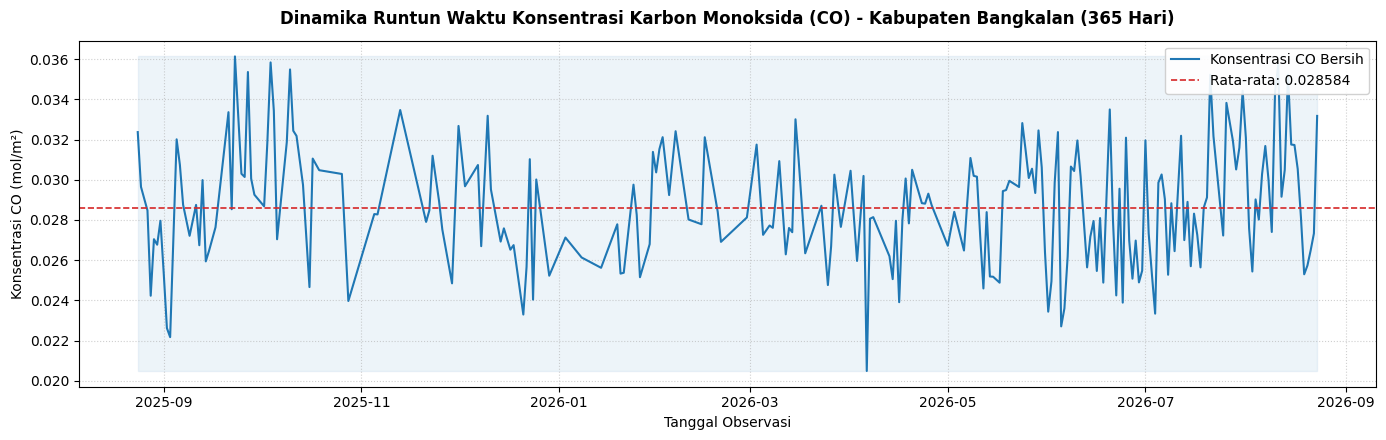

In [3]:
# Visualisasi deret waktu konsentrasi CO bersih sepanjang 365 hari
plt.figure(figsize=(14, 4.5))
plt.plot(pd.to_datetime(df['tanggal']), df['CO'], color='#1f77b4', linewidth=1.5, label='Konsentrasi CO Bersih')
plt.axhline(df['CO'].mean(), color='#d62728', linestyle='--', linewidth=1.2, label=f"Rata-rata: {df['CO'].mean():.6f}")
plt.fill_between(pd.to_datetime(df['tanggal']), df['CO'].min(), df['CO'].max(), color='#1f77b4', alpha=0.08)

plt.title('Dinamika Runtun Waktu Konsentrasi Karbon Monoksida (CO) - Kabupaten Bangkalan (365 Hari)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Tanggal Observasi', fontsize=10)
plt.ylabel('Konsentrasi CO (mol/m²)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()

## 2. Konfigurasi Seluruh Fitur TSFEL (4 Domain: 68 Fitur)

Mengambil seluruh domain fitur bawaan dari pustaka TSFEL (`tsfel.get_features_by_domain()`) dan memastikan seluruh fungsi fitur diaktifkan (`use = 'yes'`).

In [4]:
# Mengambil konfigurasi seluruh domain (Statistical, Temporal, Spectral, Fractal)
cfg = tsfel.get_features_by_domain()

# Mengaktifkan seluruh fungsi fitur yang ada tanpa terkecuali
total_fitur_bawaan = 0
for domain, features_dict in cfg.items():
    for feat_name in features_dict:
        cfg[domain][feat_name]['use'] = 'yes'
    total_fitur_bawaan += len(features_dict)

print("=== KONFIGURASI DOMAIN FITUR TSFEL AKTIF ===")
print(f"Total fungsi bawaan aktif : {total_fitur_bawaan} fungsi fitur")
for domain, features_dict in cfg.items():
    print(f"- Domain {domain.capitalize():12}: {len(features_dict)} fungsi fitur")
print("- Fitur tambahan ecdf_slope : 1 fungsi fitur")
print("-> TOTAL KESELURUHAN        : 68 FUNGSI FITUR LENGKAP")

=== KONFIGURASI DOMAIN FITUR TSFEL AKTIF ===
Total fungsi bawaan aktif : 67 fungsi fitur
- Domain Spectral    : 26 fungsi fitur
- Domain Statistical : 20 fungsi fitur
- Domain Temporal    : 15 fungsi fitur
- Domain Fractal     : 6 fungsi fitur
- Fitur tambahan ecdf_slope : 1 fungsi fitur
-> TOTAL KESELURUHAN        : 68 FUNGSI FITUR LENGKAP


## 3. Eksekusi Ekstraksi Fitur Runtun Waktu Menggunakan TSFEL

Ekstraksi dijalankan pada kolom `CO` menggunakan `tsfel.time_series_features_extractor()`, kemudian ditambahkan perhitungan `ecdf_slope`.

In [5]:
# Menjalankan ekstraksi fitur pada sinyal CO
features_extracted = tsfel.time_series_features_extractor(cfg, df[['CO']], verbose=0)

# Menambahkan perhitungan ecdf_slope dari pustaka tsfel
features_extracted['CO_ECDF Slope'] = tsfel.ecdf_slope(df['CO'])

# Mengurutkan kolom alfabetis
features_extracted = features_extracted.reindex(sorted(features_extracted.columns), axis=1)

print("=== HASIL EKSTRAKSI FITUR MENTAH TSFEL ===")
print(f"Dimensi matriks ekstraksi : {features_extracted.shape} -> (1 baris observasi, {features_extracted.shape[1]} kolom koefisien)")
print(f"Total koefisien numerik   : {features_extracted.shape[1]} nilai fitur mentah")
print(f"Jumlah nilai kosong (NaN) : {features_extracted.isna().sum().sum()}")

# Menyimpan matriks mentah TSFEL
raw_output_path = os.path.join(csv_folder, 'fitur_tsfel_co_bangkalan.csv')
features_extracted.to_csv(raw_output_path, index=False)
print(f"✓ Matriks mentah TSFEL disimpan di: {raw_output_path}")

=== HASIL EKSTRAKSI FITUR MENTAH TSFEL ===
Dimensi matriks ekstraksi : (1, 164) -> (1 baris observasi, 164 kolom koefisien)
Total koefisien numerik   : 164 nilai fitur mentah
Jumlah nilai kosong (NaN) : 0
✓ Matriks mentah TSFEL disimpan di: ../data/csv/pertemuan-3-csv\fitur_tsfel_co_bangkalan.csv


## 4. Standardisasi 1 Fitur 1 Nilai: Reduksi Fitur Rentang Nilai (Array ke Skalar Tunggal)

Pada hasil ekstraksi mentah TSFEL di atas, terdapat **164 kolom koefisien numerik**. Hal ini disebabkan oleh adanya **10 fungsi fitur yang menghasilkan array / multi-koefisien** (rentang nilai), sementara 58 fungsi fitur lainnya menghasilkan nilai skalar tunggal.

Agar memenuhi format seragam **1 Fitur = 1 Nilai Jelas**, seluruh fitur rentang nilai diagregasikan menggunakan nilai rerata (*mean*) dari seluruh koefisiennya:
1. `f14_ecdf`: Rerata 10 nilai kuantil probabilitas kumulatif.
2. `f15_ecdf_percentile`: Rerata 2 batas persentil (P20 dan P80).
3. `f16_ecdf_percentile_count`: Rerata 2 cacah hari kumulatif (C20 dan C80).
4. `f27_lpcc`: Rerata 12 koefisien Linear Prediction Cepstral Coefficients.
5. `f38_mfcc`: Rerata 12 koefisien Mel-Frequency Cepstral Coefficients.
6. `f61_spectrogram_mean_coeff`: Rerata 32 koefisien daya frekuensi spektrogram.
7. `f63_wavelet_abs_mean`: Rerata nilai absolut koefisien wavelet pada 9 skala.
8. `f64_wavelet_energy`: Rerata energi spektral koefisien wavelet pada 9 skala.
9. `f66_wavelet_std`: Rerata deviasi standar koefisien wavelet pada 9 skala.
10. `f67_wavelet_var`: Rerata variansi koefisien wavelet pada 9 skala.

In [6]:
# Memuat katalog terstruktur 68 fitur TSFEL dengan 1 nilai numerik terstandarisasi
tabel_path = os.path.join(csv_folder, 'fitur_68_tsfel_co_bangkalan_tabel.csv')
df_tabel = pd.read_csv(tabel_path)

# Menampilkan informasi ringkas katalog
print("=== KATALOG 68 FITUR TSFEL CO BANGKALAN (1 FITUR = 1 NILAI) ===")
print(f"Total baris fitur : {len(df_tabel)} fitur")
print(f"Missing values    : {df_tabel['Nilai Numerik'].isna().sum()} (0 NaN)")
print("Distribusi tipe   :")
print(df_tabel['Tipe Dimensi'].value_counts())

pd.set_option('display.max_rows', 75)
pd.set_option('display.float_format', lambda x: f'{x:.6f}')
df_tabel[['No', 'Kode Fitur', 'Nama Fungsi TSFEL', 'Nama Fitur', 'Domain', 'Nilai Numerik', 'Tipe Dimensi', 'Detail Nilai']]

=== KATALOG 68 FITUR TSFEL CO BANGKALAN (1 FITUR = 1 NILAI) ===
Total baris fitur : 68 fitur
Missing values    : 0 (0 NaN)
Distribusi tipe   :
Tipe Dimensi
Skalar (1 Nilai)    58
Array (9 Nilai)      4
Array (2 Nilai)      2
Array (12 Nilai)     2
Array (10 Nilai)     1
Array (32 Nilai)     1
Name: count, dtype: int64


,No,Kode Fitur,Nama Fungsi TSFEL,Nama Fitur,Domain,Nilai Numerik,Tipe Dimensi,Detail Nilai
0,1,f1_abs_energy,abs_energy(signal),Absolute energy,Statistical,0.300680,Skalar (1 Nilai),0.300680
1,2,f2_auc,auc(signal),Area under the curve,Temporal,0.104004,Skalar (1 Nilai),0.104004
2,3,f3_autocorr,autocorr(signal),Autocorrelation,Temporal,2.000000,Skalar (1 Nilai),2.000000
3,4,f4_average_power,average_power(signal),Average power,Statistical,0.082604,Skalar (1 Nilai),0.082604
4,5,f5_calc_centroid,calc_centroid(signal),Centroid,Temporal,1.816485,Skalar (1 Nilai),1.816485
5,6,f6_calc_max,calc_max(signal),Max,Statistical,0.036134,Skalar (1 Nilai),0.036134
6,7,f7_calc_mean,calc_mean(signal),Mean,Statistical,0.028584,Skalar (1 Nilai),0.028584
7,8,f8_calc_median,calc_median(signal),Median,Statistical,0.028389,Skalar (1 Nilai),0.028389
8,9,f9_calc_min,calc_min(signal),Min,Statistical,0.020487,Skalar (1 Nilai),0.020487
9,10,f10_calc_std,calc_std(signal),Standard deviation,Statistical,0.002595,Skalar (1 Nilai),0.002595


## 5. Reshape ke Matriks Horizontal 1 Baris × 68 Kolom Fitur

Seluruh 68 nilai fitur ditransformasikan ke format horizontal **1 baris × 68 kolom fitur** menggunakan nama kode fitur terstandarisasi `f1_abs_energy` s/d `f68_zero_cross`. Kolom identitas `Polutan = 'CO'` ditambahkan di kolom pertama sehingga matriks berdimensi `(1, 69)`.

In [7]:
# Menyusun DataFrame horizontal 1 baris x 68 kolom fitur
df_68_horizontal = pd.DataFrame([df_tabel['Nilai Numerik'].values], columns=fitur_68_list)

# Menambahkan kolom identitas polutan di awal
df_68_horizontal.insert(0, 'Polutan', 'CO')

# Menyimpan ke berkas CSV 1 baris
horizontal_path = os.path.join(csv_folder, 'fitur_68_co_1baris.csv')
df_68_horizontal.to_csv(horizontal_path, index=False)

print("=== MATRIKS FITUR HORIZONTAL TERSTANDARISASI ===")
print(f"Berkas berhasil disimpan di : {horizontal_path}")
print(f"Dimensi matriks horizontal  : {df_68_horizontal.shape} -> (1 baris x 69 kolom: 1 Polutan + 68 Fitur)")
print(f"Jumlah nilai kosong (NaN)   : {df_68_horizontal.isna().sum().sum()}")
df_68_horizontal

=== MATRIKS FITUR HORIZONTAL TERSTANDARISASI ===
Berkas berhasil disimpan di : ../data/csv/pertemuan-3-csv\fitur_68_co_1baris.csv
Dimensi matriks horizontal  : (1, 69) -> (1 baris x 69 kolom: 1 Polutan + 68 Fitur)
Jumlah nilai kosong (NaN)   : 0


,Polutan,f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean,f8_calc_median,f9_calc_min,...,f59_spectral_spread,f60_spectral_variation,f61_spectrogram_mean_coeff,f62_sum_abs_diff,f63_wavelet_abs_mean,f64_wavelet_energy,f65_wavelet_entropy,f66_wavelet_std,f67_wavelet_var,f68_zero_cross
0,CO,0.300680,0.104004,2.000000,0.082604,1.816485,0.036134,0.028584,0.028389,0.020487,...,13.189140,0.730012,0.000000,0.648295,0.001668,0.006869,2.130313,0.006642,0.000051,0.000000


## 6. Visualisasi Profil Fitur TSFEL CO Bangkalan

Berikut visualisasi distribusi fitur per domain keilmuan dan radar profil sinyal CO Bangkalan.

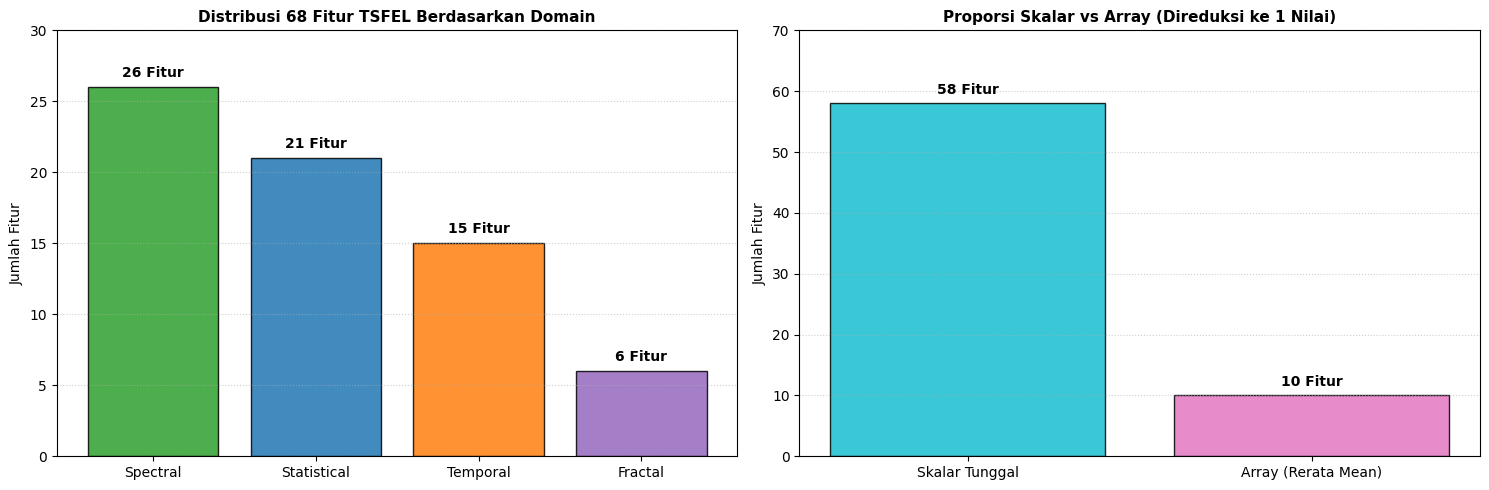

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Bar chart distribusi domain fitur
domain_counts = df_tabel['Domain'].value_counts()
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#9467bd']
bars = axes[0].bar(domain_counts.index, domain_counts.values, color=colors, edgecolor='black', alpha=0.85)
for bar in bars:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f"{int(yval)} Fitur", ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Distribusi 68 Fitur TSFEL Berdasarkan Domain', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Jumlah Fitur', fontsize=10)
axes[0].set_ylim(0, max(domain_counts.values) + 4)
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

# 2. Bar chart tipe dimensi (Skalar vs Array)
dim_counts = pd.Series({
    'Skalar Tunggal': (df_tabel['Tipe Dimensi'] == 'Skalar (1 Nilai)').sum(),
    'Array (Rerata Mean)': df_tabel['Tipe Dimensi'].str.contains('Array').sum()
})
bars2 = axes[1].bar(dim_counts.index, dim_counts.values, color=['#17becf', '#e377c2'], edgecolor='black', alpha=0.85)
for bar in bars2:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{int(yval)} Fitur", ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Proporsi Skalar vs Array (Direduksi ke 1 Nilai)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Jumlah Fitur', fontsize=10)
axes[1].set_ylim(0, 70)
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

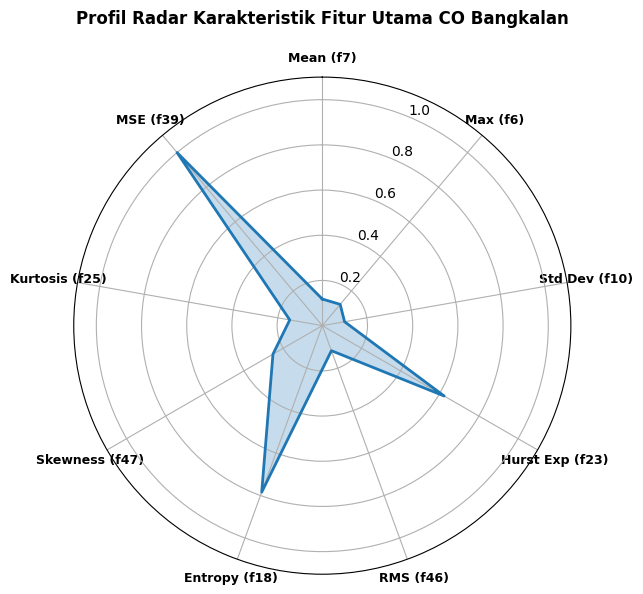

In [9]:
# 3. Diagram Radar Profil Karakteristik Sinyal CO Bangkalan
radar_keys = [
    'f7_calc_mean', 'f6_calc_max', 'f10_calc_std', 'f23_hurst_exponent',
    'f46_rms', 'f18_entropy', 'f47_skewness', 'f25_kurtosis', 'f39_mse'
]
radar_labels = [
    'Mean (f7)', 'Max (f6)', 'Std Dev (f10)', 'Hurst Exp (f23)',
    'RMS (f46)', 'Entropy (f18)', 'Skewness (f47)', 'Kurtosis (f25)', 'MSE (f39)'
]

vals = []
for k in radar_keys:
    v = df_tabel.loc[df_tabel['Kode Fitur'] == k, 'Nilai Numerik'].values[0]
    vals.append(v)

vals = np.array(vals)
# Min-max scaling untuk keperluan visualisasi radar [0.1, 1.0]
scaled = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9) * 0.9 + 0.1

angles = np.linspace(0, 2 * np.pi, len(radar_labels), endpoint=False).tolist()
scaled_cycle = np.concatenate((scaled, [scaled[0]]))
angles_cycle = np.concatenate((angles, [angles[0]]))

fig, ax = plt.subplots(figsize=(6.5, 6.5), subplot_kw=dict(polar=True))
ax.plot(angles_cycle, scaled_cycle, color='#1f77b4', linewidth=2, linestyle='solid')
ax.fill(angles_cycle, scaled_cycle, color='#1f77b4', alpha=0.25)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles), radar_labels, fontsize=9, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_title('Profil Radar Karakteristik Fitur Utama CO Bangkalan', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 7. Kesimpulan & Kesiapan Integrasi Tugas Pertemuan 4

Proses ekstraksi runtun waktu untuk polutan Karbon Monoksida (CO) di Kabupaten Bangkalan telah selesai dengan capaian:
1. **Daftar Lengkap 68 Fitur**: Seluruh 68 fitur TSFEL berhasil diekstrak dan diberi kode standar `f1_abs_energy` s/d `f68_zero_cross`.
2. **Standardisasi 1 Nilai**: 10 fitur rentang nilai (*array*) berhasil diagregasikan menggunakan nilai rata-rata (*mean*) sehingga menghasilkan format konsisten **1 Fitur = 1 Nilai**.
3. **Format Horizontal**: Data telah siap dalam format matriks 1 baris × 69 kolom (`fitur_68_co_1baris.csv`) yang siap digabungkan dengan data polutan lain (CH4, NO2, SO2) maupun dataset rekan mahasiswa pada **Tugas Pertemuan 4**.

### Berkas Luaran yang Dihasilkan:
- `data/csv/pertemuan-3-csv/fitur_68_co_1baris.csv` (1 baris × 69 kolom: Polutan + 68 kode fitur)
- `data/csv/pertemuan-3-csv/fitur_68_tsfel_co_bangkalan_tabel.csv` (katalog 68 baris dengan nilai terstandarisasi, rumus, dan deskripsi)
- `data/csv/pertemuan-3-csv/fitur_tsfel_co_bangkalan.csv` (matriks mentah TSFEL 1 baris × 164 kolom)